Introduction 

The dataset I am working with is a list of gross domestic product percent quarterly growth statistics for the United States' economy between Q1 2010 and Q4 2023, as reported by the United States Bureau of Economic Analysis. In order to effectively evaluate this dataset, I will be employing the use of the least squares method, a polynomial fit method, and cubic spline interpolation. 


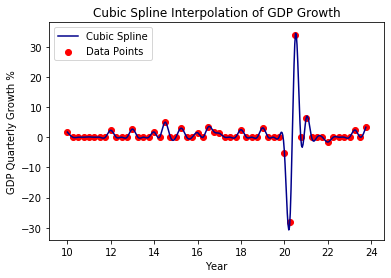

How many unknowns are there? 
 Because a cubic is generated between each adjacent datapoint, and each cubic has 4 coefficients, there are 4 unknowns per gap. We have 20 pieces of data, so 19 gaps. 4*19 = 76. We have 76 unknowns. 
 
 What are the continuity conditions at each interior knot? 
 At each interior knot, the first derivative will match the second derivative, ensuring a smooth interpolation.
 
 Is the interpolant visually smooth and reasonable? 
 The interpolant is visually smooth, however it is not necessarily reasonable given the significant distortion that crops up near 2020-2021, going as far as distorting 2018 as well. This is fabricating the experience in 2019. It seems reasonable for 2010-2017.

 Discuss the Runge phenomenon and the trade-off between exact interpolation and numerical stability: 
 The Runge Phenomenon is the tendency for high-degree polynomial solutions to create an aggressive oscillation on some interval. This is not necessarily what we are seeing in ou

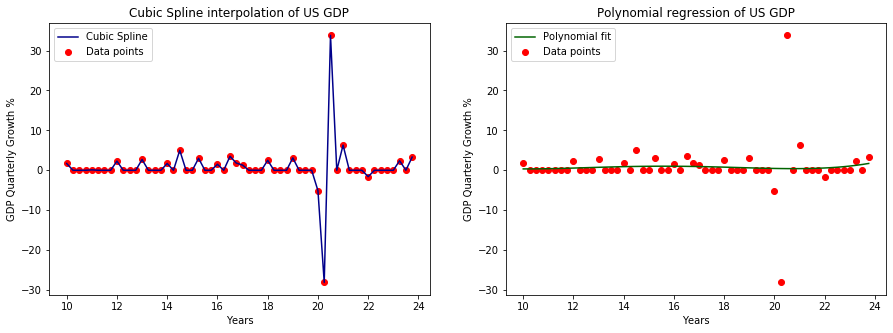

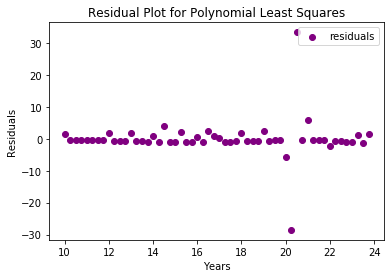

As we can see from the comparison of the two plots, the cubic spline does a much better job of recreating the dataset. This---for a more consistent dataset---could be very helpful. However, our polynomial fit does a significantly better job at recreating the overall trend of the data, without being severely skewed by the outlier data. While my polynomial fit would be a poor representation of the particular numbers that I would see in future economic quarters, it would do a better job to show what the progress would look like over time. If I wanted to know more specific data, like what was the percentage growth in quarter 2 of 2016, I should reference the cubic spline, as long as I knew the interpolation was not skewed as it is now, because it will provide a better interpolation in spaces that are not close to the outlier data

 Some key features to notice from the two graphs is that economic progress is cyclical in nature, this is captured by the cubic spline, and absent in the polynom

TypeError: can't multiply sequence by non-int of type 'numpy.float64'

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import time

#initial data
quarterList = [
10.00, 10.25, 10.50, 10.75,
11.00, 11.25, 11.50, 11.75,
12.00, 12.25, 12.50, 12.75,
13.00, 13.25, 13.50, 13.75,
14.00, 14.25, 14.50, 14.75,
15.00, 15.25, 15.50, 15.75,
16.00, 16.25, 16.50, 16.75,
17.00, 17.25, 17.50, 17.75,
18.00, 18.25, 18.50, 18.75,
19.00, 19.25, 19.50, 19.75,
20.00, 20.25, 20.50, 20.75,
21.00, 21.25, 21.50, 21.75,
22.00, 22.25, 22.50, 22.75,
23.00, 23.25, 23.50, 23.75
]

growthList = [
1.7, 0.0, 0.0, 0.0,
0.1, 0.0, 0.0, 0.0,
2.3, 0.0, 0.0, 0.0,
2.7, 0.0, 0.0, 0.0,
1.7, 0.0, 5.0, 0.0,
0.0, 3.0, 0.0, 0.0,
1.5, 0.0, 3.5, 1.8,
1.3, 0.0, 0.0, 0.0,
2.5, 0.0, 0.0, 0.0,
3.1, 0.0, 0.0, 0.0,
-5.1, -28.1, 33.8, 0.0,
6.3, 0.0, 0.0, 0.0,
-1.6, 0.0, 0.0, 0.0,
0.0, 2.4, 0.0, 3.3
]

#arrays
x = np.array(quarterList)
y = np.array(growthList)

n = len(x)

#starting cubic time
cubicTimeStart = time.perf_counter()

#length between points
h = np.diff(x)

#initializing
a = np.zeros(n)
b = np.zeros(n)
c = np.zeros(n)
d = np.zeros(n)

#boundaries
b[0] = 1
b[-1] = 1
d[0] = 0
d[-1] = 0

#creating tridiagonal matrix and constraints
for i in range(1, n-1):
    a[i] = h[i-1]
    b[i] = 2 * (h[i-1] + h[i])
    c[i] = h[i]
    
    d[i] = 6 * ((y[i+1] - y[i]) / h[i] - (y[i] - y[i-1]) / h[i-1])

#solve, Thomas Algorithm, forward elimination
for i in range(1, n):
    w = a[i] / b[i-1]
    b[i] = b[i] - w * c[i-1]
    d[i] = d[i] - w * d[i-1]

#solve, Thomas Algorithm, back substitution
M = np.zeros(n)
M[-1] = d[-1] / b[-1]
for i in range(n-2, -1, -1):
    M[i] = (d[i] - c[i] * M[i+1]) / b[i]

#evaluating the spline
def evaluate_spline(x_val, x, y, M, h):
    # find interval
    i = np.searchsorted(x, x_val) - 1
    i = max(0, min(i, len(x)-2))

    #manage the spline spacing
    xi, xi1 = x[i], x[i+1]
    hi = h[i]
    #manage the curvature
    term1 = M[i] * (xi1 - x_val)**3 / (6 * hi)
    term2 = M[i+1] * (x_val - xi)**3 / (6 * hi)
    term3 = (y[i] - M[i] * hi**2 / 6) * (xi1 - x_val) / hi
    term4 = (y[i+1] - M[i+1] * hi**2 / 6) * (x_val - xi) / hi

    return term1 + term2 + term3 + term4

#creates a plot of the spline with 400 points
x_dense = np.linspace(x[0], x[-1], 400)
y_spline = [evaluate_spline(xi, x, y, M, h) for xi in x_dense]

#ending cubic time
cubicTimeEnd = time.perf_counter()
cubicElapsedTime = cubicTimeEnd-cubicTimeStart

#plot the cubic spline
plt.plot(x_dense, y_spline, color = "darkblue", label="Cubic Spline")
plt.scatter(x, y, color='red', label="Data Points")
plt.xlabel("Year")
plt.ylabel("GDP Quarterly Growth %")
plt.legend()
plt.title("Cubic Spline Interpolation of GDP Growth")

#Introduction
print("Introduction \n")
print("The dataset I am working with is a list of gross domestic product percent quarterly growth statistics for the "
      "United States' economy between Q1 2010 and Q4 2023, as reported by the United States Bureau of Economic Analysis. "
      "In order to effectively evaluate this dataset, I will be employing the use of the least squares method, a "
      "polynomial fit method, and cubic spline interpolation. ")

plt.show()

#Discussion
print("How many unknowns are there? \n Because a cubic is generated between each adjacent datapoint, and each cubic has "
      "4 coefficients, there are 4 unknowns per gap. We have 20 pieces of data, so 19 gaps. 4*19 = 76. We have 76 unknowns. "
      "\n \n What are the continuity conditions at each interior knot? \n At each interior knot, the first derivative will "
      "match the second derivative, ensuring a smooth interpolation.\n \n Is the interpolant visually smooth and "
      "reasonable? \n The interpolant is visually smooth, however it is not necessarily reasonable given the significant "
      "distortion that crops up near 2020-2021, going as far as distorting 2018 as well. This is fabricating the "
      "experience in 2019. It seems reasonable for 2010-2017.")
print("\n Discuss the Runge phenomenon and the trade-off between exact interpolation and numerical stability: \n The "
      "Runge Phenomenon is the tendency for high-degree polynomial solutions to create an aggressive oscillation on some "
      "interval. This is not necessarily what we are seeing in our graph---our polynomial is only a cubic. By using the "
      "cubic spline method, we have constrained our interpolation to hit all datapoints, under the premise that our given "
      "dataset does not include any outliers. This usually creates a very smooth and simple interpolation of what the "
      "unknown data could look like. However, for this dataset, 2020 is a severe outlier. The oscillation in my graph is a "
      "result from my cubic spline solution attempting to account for the outlier data in 2020 and 2021, thereby affecting "
      "a significant portion of my graph---2018 through 2023.  \n \n Would smoothing splines or weighted least squares be "
      "preferable here? \n In this case, exact interpolation is a bad idea, because not all of our data is an accurate "
      "representation of the economic progress of the United States. A better choice would be approximating the data with "
      "a weighted least squares solution, minimizing the effect of the outlier data.")

#Part 2
import matplotlib.pyplot as plt
import numpy as np

#Starting polynomial computing time
polyTimeStart = time.perf_counter()
# Create Vandermonde matrix
x = [
10.00, 10.25, 10.50, 10.75,
11.00, 11.25, 11.50, 11.75,
12.00, 12.25, 12.50, 12.75,
13.00, 13.25, 13.50, 13.75,
14.00, 14.25, 14.50, 14.75,
15.00, 15.25, 15.50, 15.75,
16.00, 16.25, 16.50, 16.75,
17.00, 17.25, 17.50, 17.75,
18.00, 18.25, 18.50, 18.75,
19.00, 19.25, 19.50, 19.75,
20.00, 20.25, 20.50, 20.75,
21.00, 21.25, 21.50, 21.75,
22.00, 22.25, 22.50, 22.75,
23.00, 23.25, 23.50, 23.75
]

y = [
1.7, 0.0, 0.0, 0.0,
0.1, 0.0, 0.0, 0.0,
2.3, 0.0, 0.0, 0.0,
2.7, 0.0, 0.0, 0.0,
1.7, 0.0, 5.0, 0.0,
0.0, 3.0, 0.0, 0.0,
1.5, 0.0, 3.5, 1.8,
1.3, 0.0, 0.0, 0.0,
2.5, 0.0, 0.0, 0.0,
3.1, 0.0, 0.0, 0.0,
-5.1, -28.1, 33.8, 0.0,
6.3, 0.0, 0.0, 0.0,
-1.6, 0.0, 0.0, 0.0,
0.0, 2.4, 0.0, 3.3
]
degree = 4
V = np.vander(x, N=degree+1, increasing=True)

#creating normal equations
Vs = np.dot(V.T, V)
Vp = np.dot(V.T, y)

#solve for coefficients 
coefficients = np.linalg.solve(Vs, Vp)

#evaluates for the regression
y_predicted = V @ coefficients

#End polynomial computing time
polyTimeEnd = time.perf_counter()
polyElapsedTime = polyTimeEnd-polyTimeStart

#quantitative analysis for polynomial
mse_poly = np.mean((y - (y_predicted))**2)
ss_total = np.sum((y - np.mean(y))**2)
ss_res = np.sum((y - (y_predicted))**2)
r_squared_poly = 1 - (ss_res / ss_total)

#plotting subplot for the cubic and polynomial curves
plt.figure(figsize=(15, 5))
plt.subplot(1,2,1)
plt.scatter(x,y,color=  "red", label="Data points")
x_dense = np.linspace(x[0], x[-1], 56)
y_spline = [evaluate_spline(xi, x, y, M, h) for xi in x_dense]
plt.plot(x_dense, y_spline, color = "darkblue", label="Cubic Spline")
plt.xlabel("Years")
plt.ylabel("GDP Quarterly Growth %")
plt.title("Cubic Spline interpolation of US GDP")
plt.legend()
plt.subplot(1,2,2)
plt.scatter(x,y,color=  "red", label = "Data points")
plt.plot(x,y_predicted, color = "darkgreen", label= "Polynomial fit")
plt.xlabel("Years")
plt.ylabel("GDP Quarterly Growth %")
plt.title("Polynomial regression of US GDP")
plt.legend()
plt.show()

#plotting the residuals for polynomial
residuals_poly = y - y_predicted
plt.scatter(x, residuals_poly, color="purple", label="residuals")
plt.xlabel("Years")
plt.ylabel("Residuals")
plt.title("Residual Plot for Polynomial Least Squares")
plt.legend()
plt.show()

#discussion
print("As we can see from the comparison of the two plots, the cubic spline does a much better job of recreating the dataset. "
      "This---for a more consistent dataset---could be very helpful. However, our polynomial fit does a significantly better job " 
      "at recreating the overall trend of the data, without being severely skewed by the outlier data. While my polynomial fit "
      "would be a poor representation of the particular numbers that I would see in future economic quarters, it would do a better "
      "job to show what the progress would look like over time. If I wanted to know more specific data, like what was the "
      "percentage growth in quarter 2 of 2016, I should reference the cubic spline, as long as I knew the interpolation was not "
      "skewed as it is now, because it will provide a better interpolation in spaces that are not close to the outlier data")
print("\n Some key features to notice from the two graphs is that economic progress is cyclical in nature, this is captured "
      "by the cubic spline, and absent in the polynomial regression. However, 2018 through 2023 is skewed for the cubic " 
      "spline, however, the polynomial approximation is able to push past outliers and still show the general development of " 
      "the GDP.")

#excluding the 2020 data
x_ex = [
10.00, 10.25, 10.50, 10.75,
11.00, 11.25, 11.50, 11.75,
12.00, 12.25, 12.50, 12.75,
13.00, 13.25, 13.50, 13.75,
14.00, 14.25, 14.50, 14.75,
15.00, 15.25, 15.50, 15.75,
16.00, 16.25, 16.50, 16.75,
17.00, 17.25, 17.50, 17.75,
18.00, 18.25, 18.50, 18.75,
19.00, 19.25, 19.50, 19.75,
22.00, 22.25, 22.50, 22.75,
23.00, 23.25, 23.50, 23.75
]

y_ex = [
1.7, 0.0, 0.0, 0.0,
0.1, 0.0, 0.0, 0.0,
2.3, 0.0, 0.0, 0.0,
2.7, 0.0, 0.0, 0.0,
1.7, 0.0, 5.0, 0.0,
0.0, 3.0, 0.0, 0.0,
1.5, 0.0, 3.5, 1.8,
1.3, 0.0, 0.0, 0.0,
2.5, 0.0, 0.0, 0.0,
3.1, 0.0, 0.0, 0.0,
-1.6, 0.0, 0.0, 0.0,
0.0, 2.4, 0.0, 3.3
]
print("\n\n")

#starting linear computing time
lineTimeStart = time.perf_counter()

#least squares solving, creating matrix, solving for coefficients 
list_length = len(x_ex)
A = np.vstack([x_ex, np.ones(list_length)]).T
m, c = np.linalg.lstsq(A, y_ex, rcond=None)[0]

#ending linear computing time
lineTimeEnd = time.perf_counter()
lineElapsedTime = lineTimeEnd - lineTimeStart

#quantitative analysis for linear
mse_ls = np.mean((y_ex - (m*x_ex+c))**2)
ss_total = np.sum((y_ex - np.mean(y_ex))**2)
ss_res = np.sum((y_ex - (m*x_ex+c))**2)
r_squared = 1 - (ss_res / ss_total)

#plotting subplot of linear fit
plt.figure(figsize=(15, 5))
plt.subplot(1,2,1)
plt.scatter(x_ex,y_ex, color="navy", label = "Data points")
plt.plot(x_ex, (m*x_ex)+c, color = "red", label = "Linear fit")
plt.xlabel("Years")
plt.ylabel("GDP Quarterly Growth % ")
plt.title("Linear regression of US GDP")
plt.legend()

#plotting subplot of residuals for linear fit
plt.subplot(1,2,2)
residuals = y_ex - (m*x_ex + c)
plt.scatter(x_ex, residuals, color="purple", label="residuals")
plt.xlabel("Years")
plt.ylabel("Residuals")
plt.title("Residual Plot for Linear Regression")
plt.legend()
plt.show()
print(f'Polynomial--- Mean Squared error: {mse_poly:.4f}')
print(f'Polynomial--- r squared: {r_squared_poly:.4f}')
print(f'Least square---outliers excluded--- Mean Squared error: {mse_ls:.4f}')
print(f'Least square---outliers excluded--- r squared: {r_squared:.4f}')


print(f"\n Equation of the linear regression line: y = {m:.3f}x + {c:.3f}")
print("\n \n For this dataset, we find that the slope of a linear regression is about -0.008 % GDP change per year. A "
      "linear trend is not significantly different from a polynomial fit for this particular set of data. This is clear by "
      "comparing the r squared values of both the polynomial and linear fits. Both r squared values are very close to 0, "
      "indicating they both have a good fit for the data. The largest difference is in the MSE, which is significantly lower "
      "in the linear plot because the outliers are excluded---The polynomial has a MSE of about 100, whereas with the "
      "excluded data, the linear model has a MSE of about 2. This is not because a linear approximation is more accurate, "
      "but is more about how having reliable data drastically changes the analysis. \n\n The linear approximation does a good job "
      "of showing the general progress of the United States GDP over the decade. However, it completely removes the cyclical "
      "aspect of the data. For this small section of data, a linear trend makes economic sense to show the progress of the "
      "decade excluding the COVID breakdown. However, in general, using a linear regression necessitates the assumption that "
      "the data is liable to be linearly proportional to time. This is not usually true for economic purposes. The economy is "
      "influenced by events and choices by the government and the public. Even for very calm, uninfluenced economic activity, "
      "it is still non-linear, and cyclical in nature. This cyclical data is often used by analysts to “predict” different "
      "actions in the economy. So, for this particular set of data, the linear is pretty useful. However in reference to "
      "economic activity as a whole, linear approximations are a poor idea.")
      
#Part 3, discussion
print("\n\n Recommendation for policymaker: \n\n There are some nuances to take into consideration. \n\n "
      "If the policymaker wants to estimate GDP growth for a quarter between 2010-2018—then our cubic spline is a perfect "
      "option, as the data is smooth, predictable, numerically accurate and uninfluenced by COVID.\n\n If the policy maker "
      "wants to estimate GDP growth for a quarter between 2018-2023, the cubic spline is a poor option, having been blown "
      "out of proportion by the outlier data. Instead, they will need to gather more precise data and create a cubic spline, "
      "ensuring the highest accuracy but expending significantly more effort…or they can do an approximation with a "
      "polynomial fit, which will ensure the overall trend is preserved, while maintaining a passable level of numerical "
      "accuracy. \n\n Lastly, if the policymaker wants to be able to estimate GDP growth for some unknown quarter, any "
      "quarter along 2010-2023, then I would encourage the use of a polynomial fit, as half of the data is being disturbed "
      "by the COVID drop and spike. \n\n All data between 2018-2023 would need to be considered heavily for its accuracy for "
      "both methods, because the cubic spline will exaggerate the data, and the polynomial fit will smooth over the data.")

#big O addendum
print("\n\n What is big O notation? \n Big O notation is a method of categorizing of various programs to show how much computational "
      "expense the program has to go through to execute the code. It is a measure of computational cost. A more computationally expensive program will have its "
      "big O notation reflect that. This is a helpful tool to use when deliberating on which program is better. \n What are the big O notations of our programs? \nThe cubic "
      "spline, polynomial regression, and least squares linear solution will all have a big O notation of O(n) because they pass linearly through the list. \n It "
      "takes ", round(cubicElapsedTime, 5) , " seconds to create the cubic spline. \n It takes ", round(polyElapsedTime, 5) , " seconds to create the polynomial approximation. \n It "
      "takes ", round(lineElapsedTime, 5) , " seconds to create the least squares linear approximation. \n\n This "
      "shows an important trade off in programming; all good things come with a cost. While the cubic spline may have accuracy, it "
      "still takes more time. And while the difference is minute on this small scale, it can change runtimes considerably as n gets "
      "scaled up. This will not change my recommendations for the policymaker, because at this scale the difference is small. However, if our dataset was thousands of pieces of data long---that decision could be changed. ")
      
#Conclusion 
print("\n\n Each method---cubic, polynomial, or linear---has their pros and cons, and times in which each should be used. "
      "For a situation in which an approximation is not sufficient, and precise numerical outputs are necessary, a cubic "
      "spline is perfect. However, it mandates that all of your data is accurate and contains no outliers. For data which "
      "contains outliers or is imprecise, an approximation is usually a better choice. For example, during the years "
      "surrounding 2020; 2018,2019,2022, and 2023, I wouldn't trust the output of a cubic spline---The polynomial "
      "approximation would be better. For a constantly changing set of data, a linear fit is best. For a dataset that does "
      "not constantly change with time, a polynomial fit could be best---these have a wide range of applications. Summarily; "
      "A cubic spline is precise but demanding on the data. A polynomial fit is a goldilocks zone of medium demand from data "
      "precision, but also delivering an approximation. A linear fit is for very simple datasets, or useful to simplify data "
      "drastically to identify a general trend.  ")
print("\n For our set of data, the cubic spline was best for the accurate portion of the data---2010-2017. The quadratic "
      "should be trust after that point. The linear is not useful for much other than describing the trend of the GDP "
      "growth.  \n\n A better solution I see for this data is a set of 3 cubic splines. The first would go from 2010-2019 "
      "Q4. The next would go from 2020-2021 Q3. The last would finish off the data. I believe it would allow the data to "
      "spike and drop as it did in COVID, without influencing the economically peaceful years prior.")